## Experiment 3 — Regression Analysis (Steps 5 onward)

**Assumptions made (adjust if they don't match your setup):**
- `df` is already loaded and cleaned from your preprocessing/EDA stage (missing values handled, as in `handle_missing_values_categorical` / `handle_missing_values_numerical`).
- Dataset is the standard *Loan Prediction* dataset (`Loan_ID, Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area, Loan_Status`).
- **Target column = `LoanAmount`** (change `target_col` below if yours differs).
- Categorical features are **one-hot encoded** and included as predictors (per your choice), rather than dropped like in Assignment 2.


In [ ]:
# Core imports for the modeling stage
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### Preprocessing continuation: Encode categorical variables

This picks up where the generic EDA module left off — it doesn't encode anything, only analyzes. We encode here so the feature matrix is fully numeric before splitting.

In [1]:
import sys,os
import pandas as pd
sys.path.append(os.path.abspath('../utils'))
from eda_supervised import perform_eda


df=pd.read_csv('../datasets/loan_amt_prediction/train_u6lujuX_CVtuZ9i.csv')
target_col = "LoanAmount"   # <-- change this if your target column name differs

df_model = df.copy()

# Drop identifier columns that carry no predictive information
id_cols = [c for c in ["Loan_ID"] if c in df_model.columns]
df_model = df_model.drop(columns=id_cols)

# Rows with a missing target can't be imputed (we'd be predicting a made-up value),
# so they are dropped before any other missing-value handling.
before = len(df_model)
df_model = df_model.dropna(subset=[target_col])
print(f"Dropped {before - len(df_model)} rows with missing target ('{target_col}').")

# Identify categorical / numeric feature columns (excluding the target)
categorical_cols = df_model.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = [c for c in df_model.select_dtypes(include="number").columns if c != target_col]

# Same missing-value handling strategy used in Assignment 2:
# categorical -> mode, numeric -> mean (if ~symmetric) or median (if skewed)
def handle_missing_values_categorical(frame, cols):
    for col in cols:
        frame[col] = frame[col].fillna(frame[col].mode()[0])
    return frame

def handle_missing_values_numerical(frame, cols):
    for col in cols:
        skew = frame[col].skew()
        if -0.5 <= skew <= 0.5:
            frame[col] = frame[col].fillna(frame[col].mean())
        else:
            frame[col] = frame[col].fillna(frame[col].median())
    return frame

df_model = handle_missing_values_categorical(df_model, categorical_cols)
df_model = handle_missing_values_numerical(df_model, numeric_cols)

print("Remaining missing values:\n", df_model.isnull().sum()[df_model.isnull().sum() > 0])

# One-hot encode categorical variables (Dependents' '3+' category is kept as its own dummy)
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("\nFinal feature columns:", [c for c in df_model.columns if c != target_col])
print("Shape after encoding:", df_model.shape)


Dropped 22 rows with missing target ('LoanAmount').
Remaining missing values:
 Series([], dtype: int64)

Final feature columns: ['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Loan_Status_Y']
Shape after encoding: (592, 15)


### Step 5: Split the dataset into training and testing sets

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale numeric features — fit ONLY on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape :", X_test_scaled.shape)


Training set shape: (473, 14)
Testing set shape : (119, 14)


### Step 6: Train baseline Linear Regression

In [9]:
import time
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
start = time.time()
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
lin_train_time = time.time() - start

y_pred_lin = lin_reg.predict(X_test_scaled)

lin_metrics = {
    "MAE": mean_absolute_error(y_test, y_pred_lin),
    "MSE": mean_squared_error(y_test, y_pred_lin),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lin)),
    "R2": r2_score(y_test, y_pred_lin),
    "Training Time": lin_train_time
}

print("Baseline Linear Regression Performance")
for k, v in lin_metrics.items():
    print(f"{k}: {v:.4f}")


Baseline Linear Regression Performance
MAE: 36.9875
MSE: 3339.9218
RMSE: 57.7921
R2: 0.0940
Training Time: 0.0406


### Step 7: Train Ridge, Lasso, and Elastic Net (baseline, default hyperparameters)

In [11]:
import time
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=10000),
    "ElasticNet": ElasticNet(max_iter=10000)
}

baseline_results = {}

for name, model in baseline_models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test_scaled)

    baseline_results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "Training Time": train_time
    }

baseline_results_df = pd.DataFrame(baseline_results).T
baseline_results_df


,MAE,MSE,RMSE,R2,Training Time
Ridge,36.989293,3337.030228,57.767034,0.094768,0.027006
Lasso,36.567170,3300.180353,57.447196,0.104764,0.011061
ElasticNet,38.363264,3111.510650,55.780917,0.155944,0.005948


### Step 8: Hyperparameter tuning using 5-Fold Cross-Validation

Ridge and Lasso are tuned with `GridSearchCV` (small, discrete search spaces). Elastic Net is tuned with `RandomizedSearchCV` since it has two hyperparameters (`alpha`, `l1_ratio`), demonstrating both required search methods across the experiment.

In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# ---------- Ridge: Grid Search ----------
ridge_param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_param_grid, cv=5, scoring="r2")

start = time.time()
ridge_grid.fit(X_train_scaled, y_train)
ridge_tuning_time = time.time() - start

# ---------- Lasso: Grid Search ----------
lasso_param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_param_grid, cv=5, scoring="r2")

start = time.time()
lasso_grid.fit(X_train_scaled, y_train)
lasso_tuning_time = time.time() - start

# ---------- Elastic Net: Randomized Search ----------
elasticnet_param_dist = {
    "alpha": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8]
}
elasticnet_random = RandomizedSearchCV(
    ElasticNet(max_iter=10000),
    param_distributions=elasticnet_param_dist,
    n_iter=8,
    cv=5,
    scoring="r2",
    random_state=42
)

start = time.time()
elasticnet_random.fit(X_train_scaled, y_train)
elasticnet_tuning_time = time.time() - start

# ---------- Table 1: Hyperparameter Tuning Summary ----------
tuning_summary = pd.DataFrame({
    "Model": ["Ridge Regression", "Lasso Regression", "Elastic Net Regression"],
    "Search Method": ["Grid Search", "Grid Search", "Randomized Search"],
    "Best Parameters": [ridge_grid.best_params_, lasso_grid.best_params_, elasticnet_random.best_params_],
    "Best CV R2": [
        round(ridge_grid.best_score_, 4),
        round(lasso_grid.best_score_, 4),
        round(elasticnet_random.best_score_, 4)
    ]
})

tuning_summary


,Model,Search Method,Best Parameters,Best CV R2
0,Ridge Regression,Grid Search,{'alpha': 100},0.3358
1,Lasso Regression,Grid Search,{'alpha': 10},0.2548
2,Elastic Net Regression,Randomized Search,"{'l1_ratio': 0.8, 'alpha': 1}",0.3239


### Step 9: Evaluate all models using regression metrics

**Table 2 — Cross-Validation Performance (K = 5)**

In [13]:
from sklearn.model_selection import cross_val_score

final_models = {
    "Linear Regression": lin_reg,
    "Ridge Regression": ridge_grid.best_estimator_,
    "Lasso Regression": lasso_grid.best_estimator_,
    "Elastic Net Regression": elasticnet_random.best_estimator_
}

cv_rows = []
for name, model in final_models.items():
    mae_scores = -cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="neg_mean_absolute_error")
    mse_scores = -cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="neg_mean_squared_error")
    r2_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2")

    cv_rows.append({
        "Model": name,
        "MAE": round(mae_scores.mean(), 4),
        "MSE": round(mse_scores.mean(), 4),
        "RMSE": round(np.sqrt(mse_scores.mean()), 4),
        "R2": round(r2_scores.mean(), 4)
    })

cv_performance_table = pd.DataFrame(cv_rows)
cv_performance_table


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,45.9546,6926.3238,83.2245,0.1840
1,Ridge Regression,45.7497,5423.9669,73.6476,0.3358
2,Lasso Regression,48.3139,6170.0325,78.5496,0.2548
3,Elastic Net Regression,45.7491,5549.3157,74.4937,0.3239


**Table 3 — Test Set Performance**

In [14]:
test_rows = []
predictions = {}
training_times = {}

for name, model in final_models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)   # refit on the full training set
    training_times[name] = time.time() - start

    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    test_rows.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test, y_pred), 4),
        "MSE": round(mean_squared_error(y_test, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        "R2": round(r2_score(y_test, y_pred), 4),
        "Training Time (s)": round(training_times[name], 4)
    })

test_performance_table = pd.DataFrame(test_rows)
test_performance_table


,Model,MAE,MSE,RMSE,R2,Training Time (s)
0,Linear Regression,36.9875,3339.9218,57.7921,0.0940,0.004
1,Ridge Regression,37.4125,3167.6618,56.2820,0.1407,0.005
2,Lasso Regression,37.7959,3176.7998,56.3631,0.1382,0.004
3,Elastic Net Regression,37.3369,3160.2699,56.2163,0.1427,0.002


## Required Visualizations

**Test Set Performance Comparison**

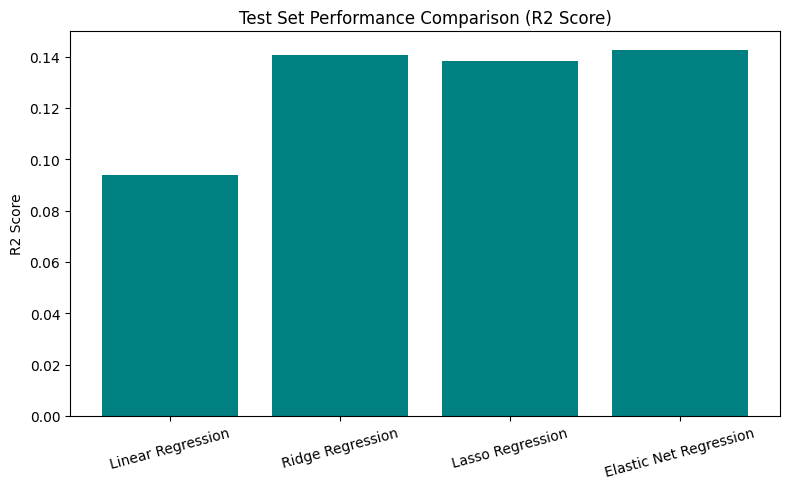

In [10]:
plt.figure(figsize=(8,5))
plt.bar(test_performance_table["Model"], test_performance_table["R2"], color="teal")
plt.ylabel("R2 Score")
plt.title("Test Set Performance Comparison (R2 Score)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Predicted vs. Actual values plot**

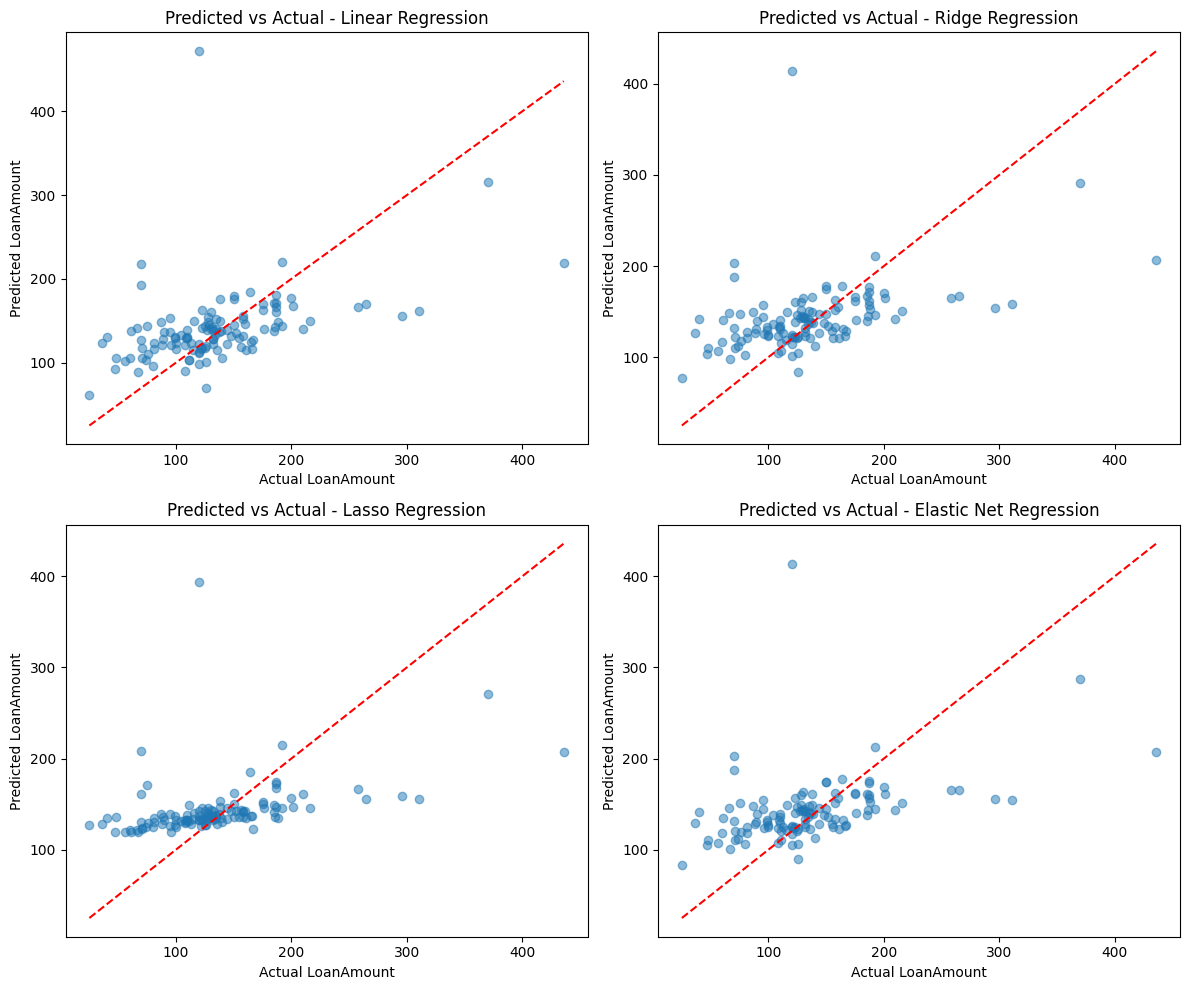

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel(f"Actual {target_col}")
    ax.set_ylabel(f"Predicted {target_col}")
    ax.set_title(f"Predicted vs Actual - {name}")

plt.tight_layout()
plt.show()


**Residual plot**

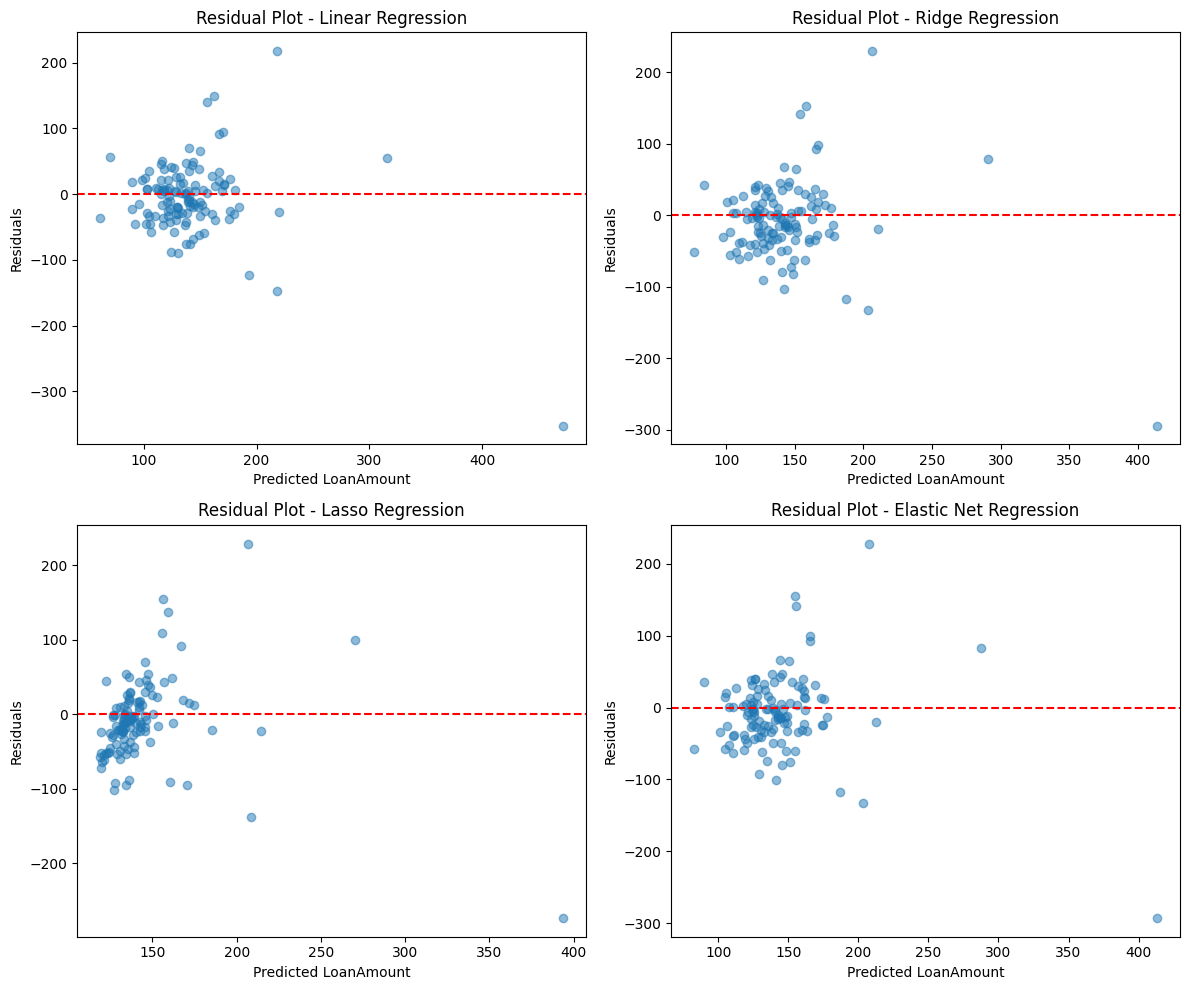

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5)
    ax.axhline(y=0, color='r', linestyle='--')
    ax.set_xlabel(f"Predicted {target_col}")
    ax.set_ylabel("Residuals")
    ax.set_title(f"Residual Plot - {name}")

plt.tight_layout()
plt.show()


**Training error vs. validation error plot** (supports the overfitting / bias–variance analysis)

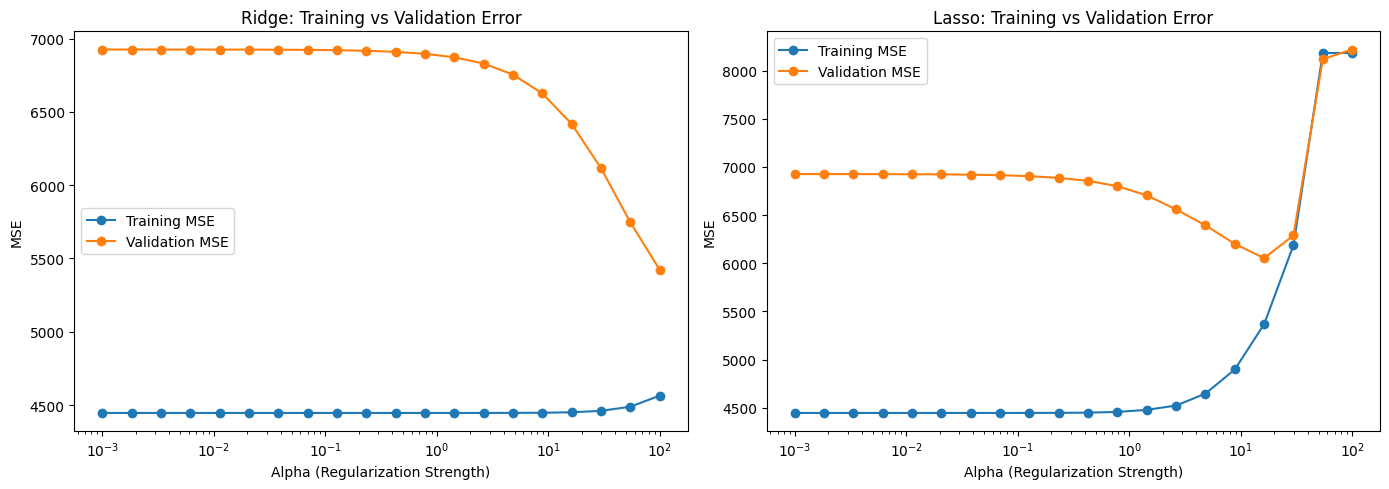

In [13]:
alphas = np.logspace(-3, 2, 20)

train_errors_ridge, val_errors_ridge = [], []
train_errors_lasso, val_errors_lasso = [], []

for a in alphas:
    ridge_model = Ridge(alpha=a).fit(X_train_scaled, y_train)
    train_errors_ridge.append(mean_squared_error(y_train, ridge_model.predict(X_train_scaled)))
    val_errors_ridge.append(
        -cross_val_score(Ridge(alpha=a), X_train_scaled, y_train, cv=5, scoring="neg_mean_squared_error").mean()
    )

    lasso_model = Lasso(alpha=a, max_iter=10000).fit(X_train_scaled, y_train)
    train_errors_lasso.append(mean_squared_error(y_train, lasso_model.predict(X_train_scaled)))
    val_errors_lasso.append(
        -cross_val_score(Lasso(alpha=a, max_iter=10000), X_train_scaled, y_train, cv=5, scoring="neg_mean_squared_error").mean()
    )

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(alphas, train_errors_ridge, marker='o', label="Training MSE")
axes[0].plot(alphas, val_errors_ridge, marker='o', label="Validation MSE")
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha (Regularization Strength)")
axes[0].set_ylabel("MSE")
axes[0].set_title("Ridge: Training vs Validation Error")
axes[0].legend()

axes[1].plot(alphas, train_errors_lasso, marker='o', label="Training MSE")
axes[1].plot(alphas, val_errors_lasso, marker='o', label="Validation MSE")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha (Regularization Strength)")
axes[1].set_ylabel("MSE")
axes[1].set_title("Lasso: Training vs Validation Error")
axes[1].legend()

plt.tight_layout()
plt.show()


**Coefficient comparison bar plot** (supports Table 4 — Effect of Regularization on Coefficients)

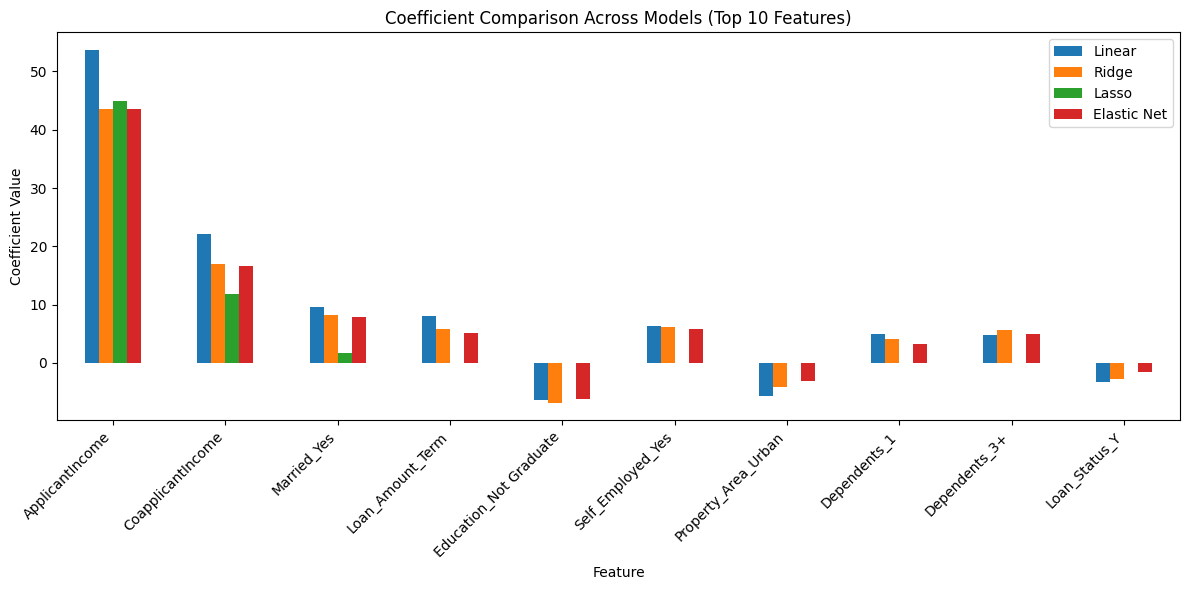

,Feature,Linear,Ridge,Lasso,Elastic Net
0,ApplicantIncome,53.683425,43.557526,44.979120,43.510059
1,CoapplicantIncome,22.064400,17.022854,11.788200,16.647215
2,Loan_Amount_Term,8.030478,5.843951,0.000000,5.120744
3,Credit_History,3.272367,2.244440,0.000000,1.160546
4,Gender_Male,0.248410,1.370360,0.000000,0.985294
5,Married_Yes,9.592533,8.208477,1.744624,7.952704
6,Dependents_1,4.882557,4.156139,0.000000,3.215929
7,Dependents_2,2.337386,1.908402,0.000000,1.105000
8,Dependents_3+,4.795103,5.630729,0.000000,4.899041
9,Education_Not Graduate,-6.423976,-6.819024,-0.000000,-6.193303


In [14]:
coef_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Linear": lin_reg.coef_,
    "Ridge": final_models["Ridge Regression"].coef_,
    "Lasso": final_models["Lasso Regression"].coef_,
    "Elastic Net": final_models["Elastic Net Regression"].coef_
})

# Keep the top 10 features by absolute Linear-Regression coefficient for readability
top_features = coef_df.reindex(coef_df["Linear"].abs().sort_values(ascending=False).index).head(10)

top_features.set_index("Feature").plot(kind="bar", figsize=(12,6))
plt.title("Coefficient Comparison Across Models (Top 10 Features)")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

coef_df


**Training time comparison**

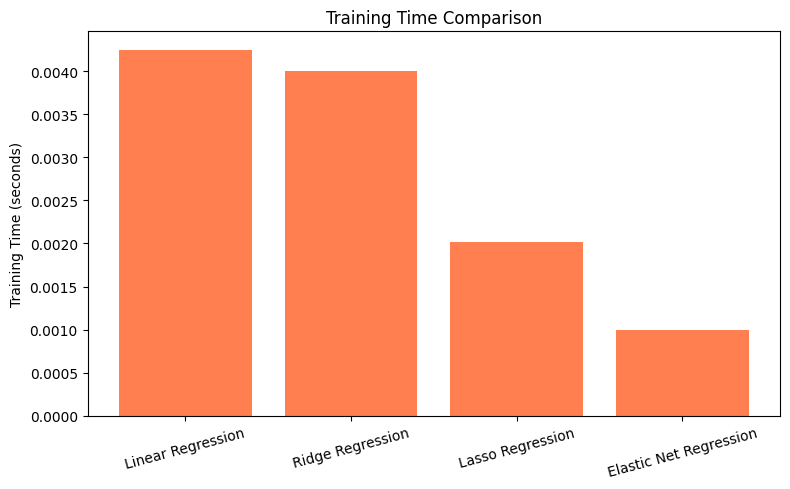

In [15]:
plt.figure(figsize=(8,5))
plt.bar(training_times.keys(), training_times.values(), color="coral")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
